# DSA 4060: Recommender Systems - Week 1 Practical
**Name:** Your Name  
**Student ID:** Your Student Number  
**Date:** September 21, 2026  
**Purpose:** Build and evaluate non-personalized popularity and weighted-rating movie recommendation baselines using MovieLens data.

In [2]:
import os
from pathlib import Path
import urllib.request
import zipfile

# 1. Setup directory paths
DATA_DIR = Path('data')
IMAGES_DIR = Path('images')
DATA_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

MOVIES_FILE = DATA_DIR / 'movies.csv'
RATINGS_FILE = DATA_DIR / 'ratings.csv'

# 2. Download MovieLens latest-small dataset
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
zip_path = "ml-latest-small.zip"

if not MOVIES_FILE.exists() or not RATINGS_FILE.exists():
    print("Downloading MovieLens dataset...")
    urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('temp_ml')

    # Move CSVs to data folder
    os.rename('temp_ml/ml-latest-small/movies.csv', MOVIES_FILE)
    os.rename('temp_ml/ml-latest-small/ratings.csv', RATINGS_FILE)
    print("Dataset successfully extracted to data/ folder.")
else:
    print("Dataset already exists.")

Dataset successfully extracted to data/ folder.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


In [4]:
print('Missing values in movies:\n', movies.isna().sum())
print('Missing values in ratings:\n', ratings.isna().sum())
print('Duplicate movie rows:', movies.duplicated().sum())
print('Duplicate rating rows:', ratings.duplicated().sum())
print('Rating range:', ratings['rating'].min(), 'to', ratings['rating'].max())
print('Unknown movie IDs:', (~ratings['movieId'].isin(movies['movieId'])).sum())

Missing values in movies:
 movieId    0
title      0
genres     0
dtype: int64
Missing values in ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Duplicate movie rows: 0
Duplicate rating rows: 0
Rating range: 0.5 to 5.0
Unknown movie IDs: 0


In [5]:
n_users = ratings['userId'].nunique()
n_movies_rated = ratings['movieId'].nunique()
n_interactions = len(ratings)

print('Unique users:', n_users)
print('Movies with at least one rating:', n_movies_rated)
print('Total rating interactions:', n_interactions)

possible_interactions = n_users * n_movies_rated
observed_interactions = n_interactions
sparsity = 1 - (observed_interactions / possible_interactions)

print(f'Possible interactions: {possible_interactions:,}')
print(f'Observed interactions: {observed_interactions:,}')
print(f'Sparsity: {sparsity:.2%}')

Unique users: 610
Movies with at least one rating: 9724
Total rating interactions: 100836
Possible interactions: 5,931,640
Observed interactions: 100,836
Sparsity: 98.30%


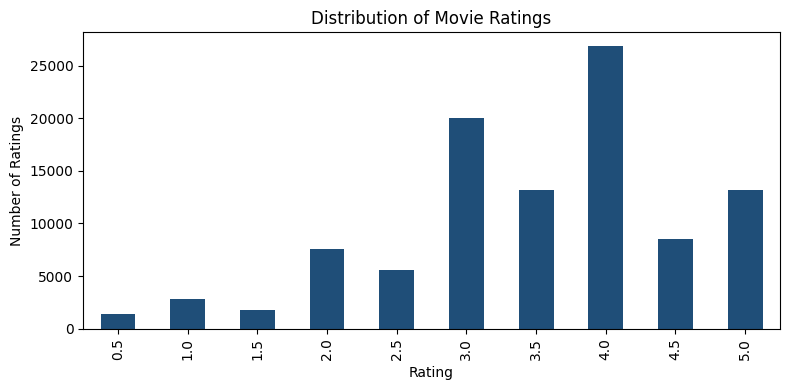

In [6]:
rating_distribution = ratings['rating'].value_counts().sort_index()

ax = rating_distribution.plot(kind='bar', color='#1F4E78', figsize=(8, 4))
ax.set_title('Distribution of Movie Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

In [7]:
movie_stats = (
    ratings.groupby('movieId')
    .agg(
        average_rating=('rating', 'mean'),
        rating_count=('rating', 'count')
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[['movieId', 'title', 'genres']],
    on='movieId',
    how='left',
    validate='one_to_one'
)

display(movie_stats.head())

,movieId,average_rating,rating_count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


In [8]:
def recommend_popular_movies(stats, min_ratings=50, top_n=10):
    candidates = stats[stats['rating_count'] >= min_ratings].copy()
    return (
        candidates.sort_values(
            ['average_rating', 'rating_count'],
            ascending=[False, False]
        )
        .head(top_n)
        [['movieId', 'title', 'genres', 'rating_count', 'average_rating']]
    )

popular_movies = recommend_popular_movies(movie_stats, min_ratings=50, top_n=10)
display(popular_movies)

,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,1276,Cool Hand Luke (1967),Drama,57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,904,Rear Window (1954),Mystery|Thriller,84,4.261905
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,1213,Goodfellas (1990),Crime|Drama,126,4.250000
694,912,Casablanca (1942),Drama|Romance,100,4.240000


In [9]:
C = ratings['rating'].mean()
m = movie_stats['rating_count'].quantile(0.90)

print(f'Overall mean rating C: {C:.3f}')
print(f'90th percentile rating count m: {m:.1f}')

qualified = movie_stats[movie_stats['rating_count'] >= m].copy()
v = qualified['rating_count']
R = qualified['average_rating']

qualified['weighted_score'] = (v / (v + m)) * R + (m / (v + m)) * C

weighted_recommendations = (
    qualified.sort_values(
        ['weighted_score', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

display(weighted_recommendations[['title', 'genres', 'rating_count', 'average_rating', 'weighted_score']])

Overall mean rating C: 3.502
90th percentile rating count m: 27.0


,title,genres,rating_count,average_rating,weighted_score
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.356227
659,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.191973
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.187927
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.160223
46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.151697
461,Schindler's List (1993),Drama|War,220,4.225000,4.145919
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,4.140844
897,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,211,4.215640,4.134630
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,4.131285
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690,4.128475


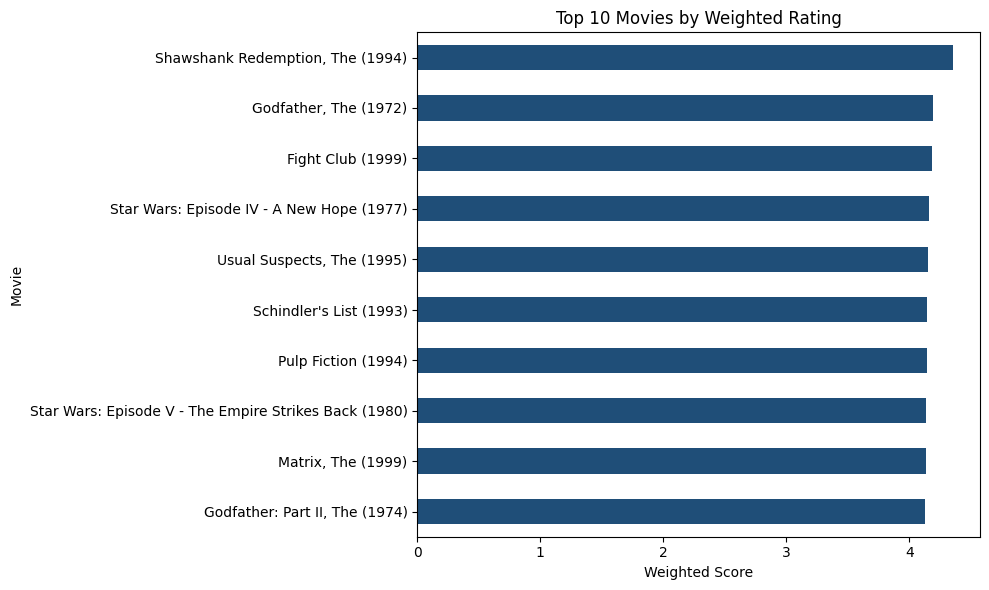

All checks passed successfully.


In [10]:
plot_data = weighted_recommendations.sort_values('weighted_score')

fig, ax = plt.subplots(figsize=(10, 6))
plot_data.plot(
    x='title',
    y='weighted_score',
    kind='barh',
    color='#1F4E78',
    legend=False,
    ax=ax
)
ax.set_title('Top 10 Movies by Weighted Rating')
ax.set_xlabel('Weighted Score')
ax.set_ylabel('Movie')
plt.tight_layout()

# Save image into images directory
plt.savefig(IMAGES_DIR / 'top10_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

# Structural checks
assert len(popular_movies) <= 10
assert popular_movies['movieId'].is_unique
assert popular_movies['rating_count'].ge(50).all()
assert popular_movies['average_rating'].between(0.5, 5.0).all()
assert popular_movies['title'].notna().all()
assert len(weighted_recommendations) <= 10
assert weighted_recommendations['weighted_score'].notna().all()

print('All checks passed successfully.')

In [11]:
from google.colab import files

# Download the generated chart
files.download('images/top10_recommendations.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>